1.Import thư viện


In [73]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

2.Đọc dữ liệu

In [74]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

3.Khám phá dữ liệu

In [75]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


4.Làm sạch dữ liệu

In [76]:
df.columns = df.columns.str.strip()
if 'customer_id' in df.columns:
    df = df.drop(['customer_id'], axis=1)
columns = ['credit_score', 'age', 'balance', 'estimated_salary']
for col in columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=columns)
print(df.shape)

(10000, 11)


5.Vẽ biểu đồ tuần suất (Histogram)

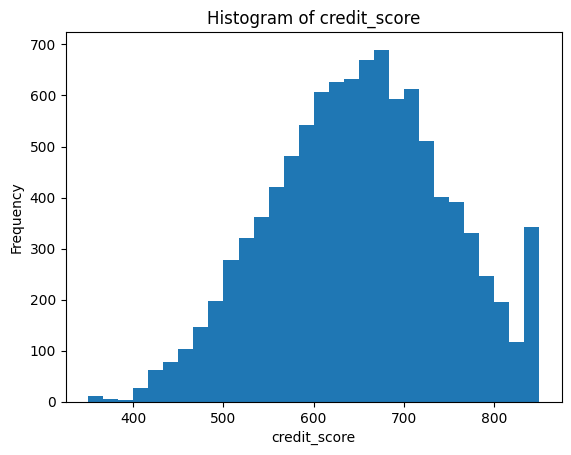

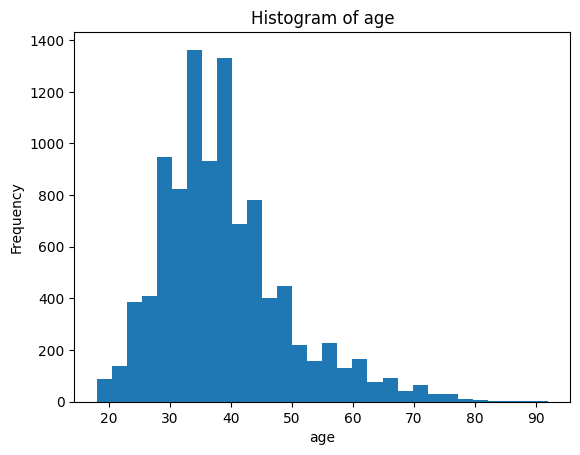

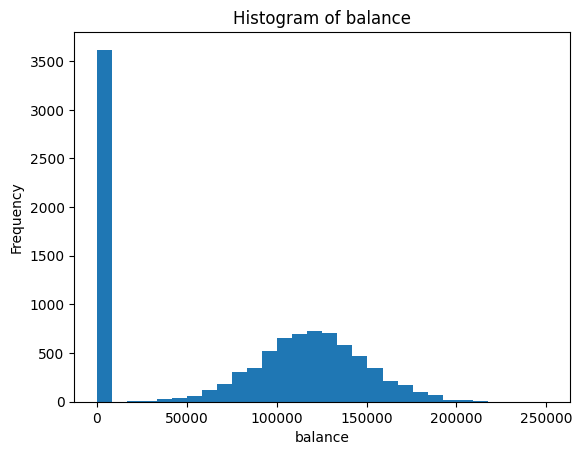

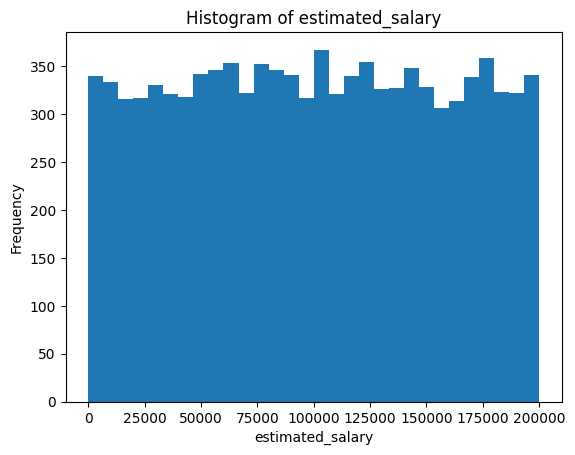

In [77]:
for col in columns:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

6.Biểu đồ hộp (Boxplot)

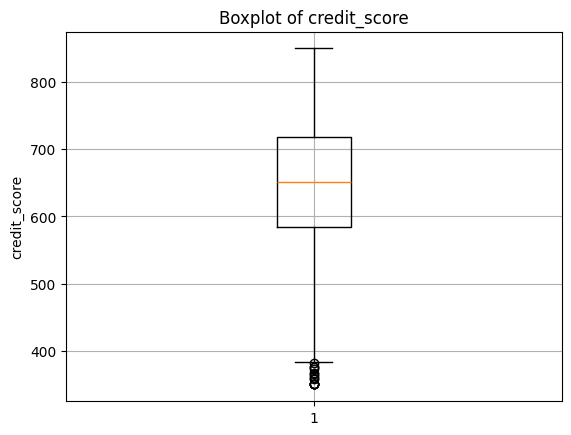

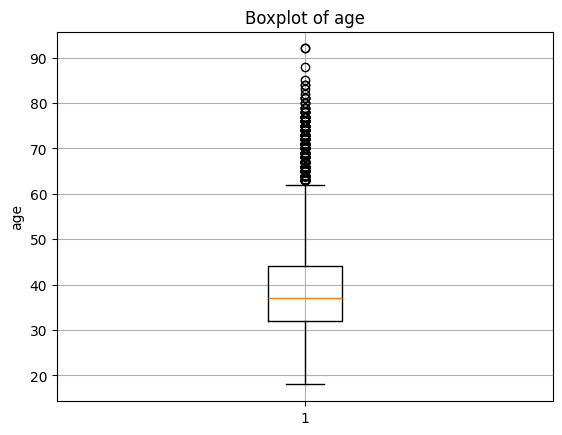

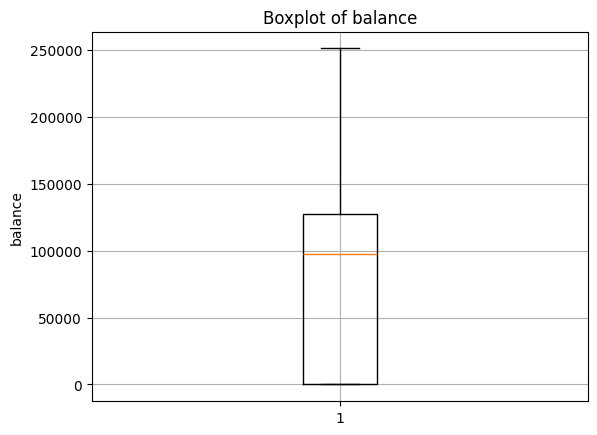

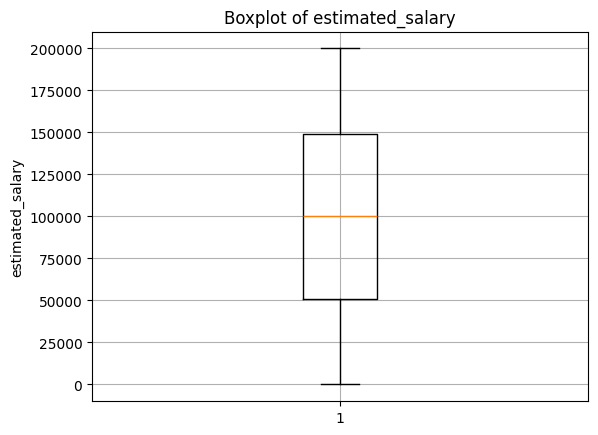

In [78]:
for col in columns:
    plt.figure()
    plt.boxplot(df[col], vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid()
    plt.show()

7.Biểu đồ mật độ (density Plot)

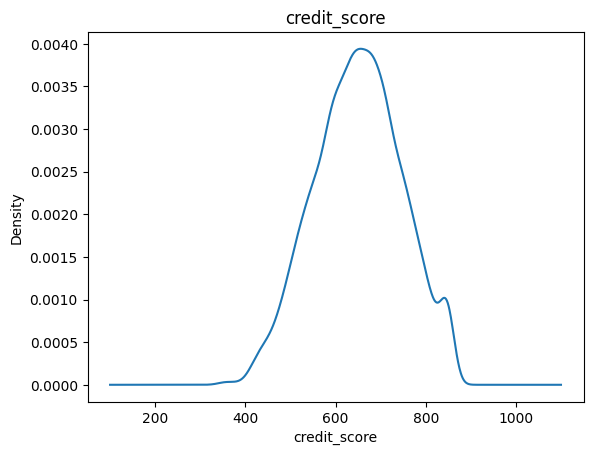

credit_score: lệch trái (đuôi bên trái dài)


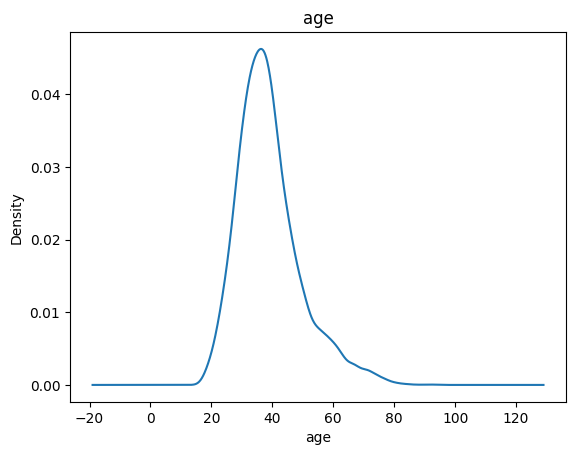

age: lệch phải (đuôi bên phải dài)


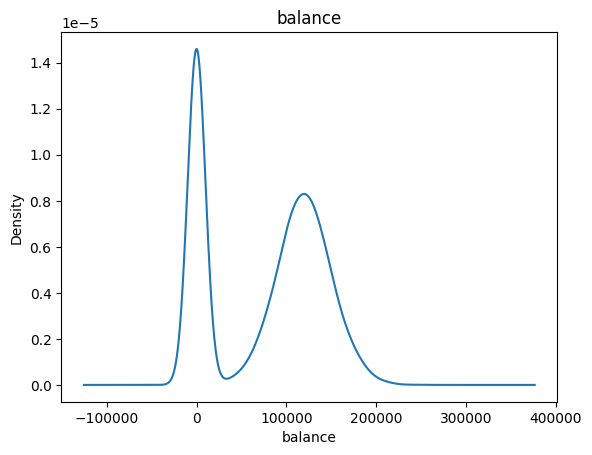

balance: lệch trái (đuôi bên trái dài)


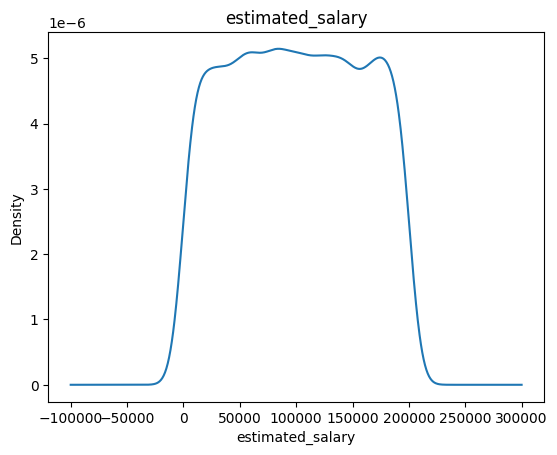

estimated_salary: lệch phải (đuôi bên phải dài)


In [79]:
for col in columns :
    plt.figure()
    df[col].plot(kind='density')
    plt.title(col)
    plt.xlabel(col)
    plt.show()
    # Nhận xét 
    skew = df[col].skew()
    
    if skew > 0:
        print(f"{col}: lệch phải (đuôi bên phải dài)")
    elif skew < 0:
        print(f"{col}: lệch trái (đuôi bên trái dài)")
    else:
        print(f"{col}: phân phối đối xứng")

9. Phát hiện Outlier(IQR)

In [80]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

credit_score: 15 outliers
age: 359 outliers
balance: 0 outliers
estimated_salary: 0 outliers


10.Xử lý Outlier

In [81]:
df_clean = df.copy()
for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]